# Analyse du Dataset Financier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('dataset_financier.csv')
data.head()

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence,banque,lieu
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,Agence_Centre,Société Générale,Bafoussam
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,Agence_Centre,UBA,Douala
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,Agence_Sud,UBA,Bafoussam
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,Agence_Centre,UBA,Douala
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,Agence_Centre,Ecobank,Bafoussam


In [3]:
data.shape

(1000, 10)

In [4]:
data.dtypes

bilan_financier    float64
actifs             float64
revenu             float64
depenses           float64
taux_interet       float64
flux_tresorerie    float64
capital            float64
agence                 str
banque                 str
lieu                   str
dtype: object

In [5]:
data.describe()

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,50289.980837,20495.853661,3004.667372,1490.640391,4.991526,9910.662587,39582.085591
std,14688.239073,6982.180641,786.763425,513.566263,2.901605,2963.913307,12364.166625
min,1380.989899,-582.720443,584.390275,35.275655,0.061838,1500.909130,5205.833442
25%,40286.145418,15756.308177,2481.600309,1131.289773,2.457276,7978.062358,30915.352716
50%,50379.509184,20441.539926,2999.799388,1500.092287,4.914739,9885.273463,39480.431990
75%,59719.158132,25102.175239,3528.732251,1833.472705,7.538136,11879.381786,48259.573668
max,107790.972360,42351.752975,6140.990165,3121.546485,9.993503,19338.730603,77179.593209


## 1 - Données manquantes

In [6]:
data.isnull().sum()

bilan_financier    0
actifs             0
revenu             0
depenses           0
taux_interet       0
flux_tresorerie    0
capital            0
agence             0
banque             0
lieu               0
dtype: int64

## 2 - Doublons

In [7]:
duplicates = data.duplicated()
duplicates.value_counts()

False    1000
Name: count, dtype: int64

In [8]:
data = data.drop_duplicates()
data.shape

(1000, 10)

## 3 - Outliers

<Axes: xlabel='bilan_financier'>

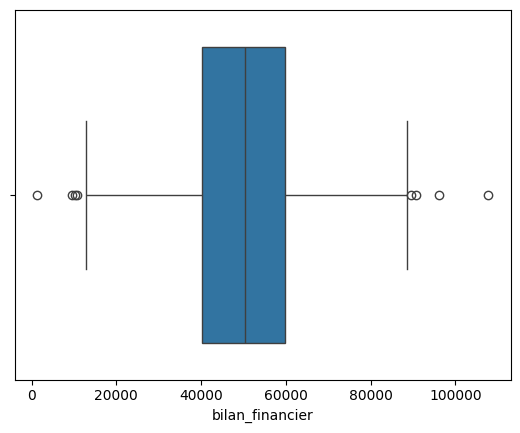

In [9]:
# boxplots pour détecter les outliers
sns.boxplot(x='bilan_financier', data=data)

<Axes: xlabel='flux_tresorerie'>

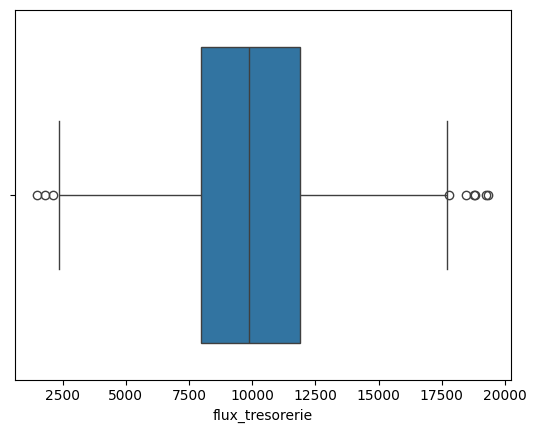

In [10]:
sns.boxplot(x='flux_tresorerie', data=data)

In [11]:
# q1= 25% q3=75%
# Traitement des outliers
def replace_outliers(df):
    for col in df.select_dtypes(include=['number']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

<Axes: xlabel='bilan_financier'>

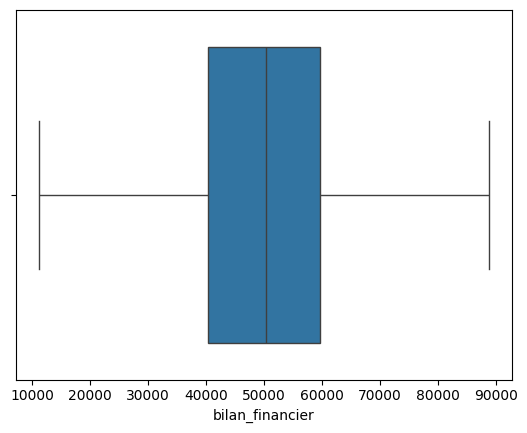

In [12]:
replace_outliers(data)
sns.boxplot(x='bilan_financier', data=data)

## Exploratory Data Analysis (EDA)

### Analyse univariée

<Axes: xlabel='bilan_financier', ylabel='Count'>

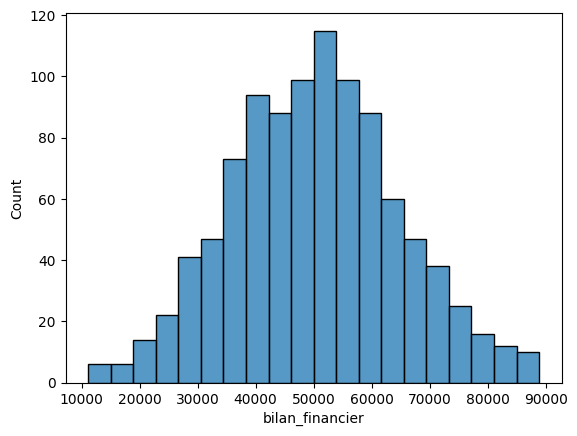

In [13]:
# histogramme du bilan financier
sns.histplot(x='bilan_financier', data=data)

<Axes: xlabel='capital', ylabel='Count'>

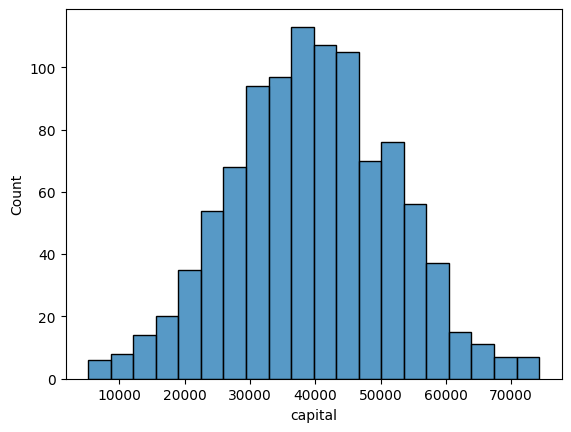

In [14]:
# histogramme du capital
sns.histplot(x='capital', data=data)

C:\Users\Lowe\AppData\Local\Temp\ipykernel_19516\1603128823.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='banque', data=data, palette='muted')


<Axes: xlabel='banque', ylabel='count'>

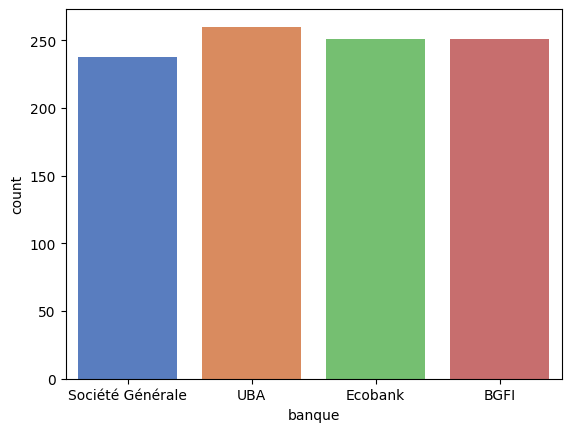

In [15]:
# répartition par banque
sns.countplot(x='banque', data=data, palette='muted')

<Axes: xlabel='lieu', ylabel='count'>

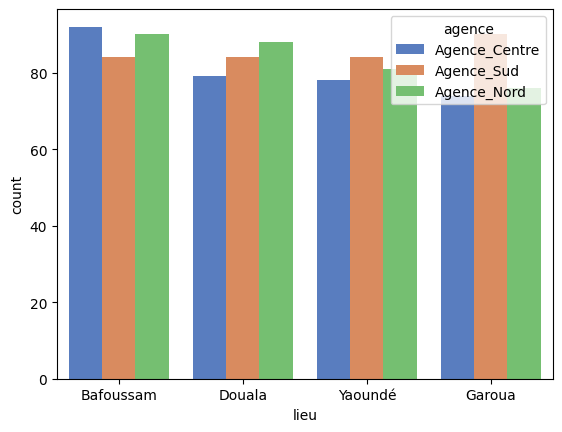

In [16]:
# répartition par lieu
sns.countplot(x='lieu', data=data, hue='agence', palette='muted')

### Analyse bivariée

C:\Users\Lowe\AppData\Local\Temp\ipykernel_19516\1928302436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='banque', y='bilan_financier', data=data, palette='muted')


<Axes: xlabel='banque', ylabel='bilan_financier'>

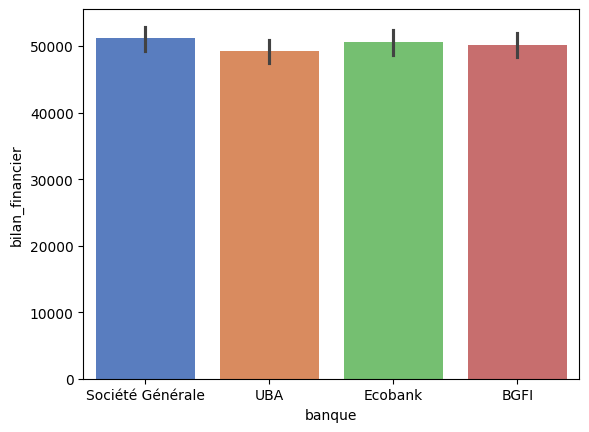

In [17]:
# bilan financier par banque
sns.barplot(x='banque', y='bilan_financier', data=data, palette='muted')

C:\Users\Lowe\AppData\Local\Temp\ipykernel_19516\2065699024.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='lieu', y='revenu', data=data, palette='muted')


<Axes: xlabel='lieu', ylabel='revenu'>

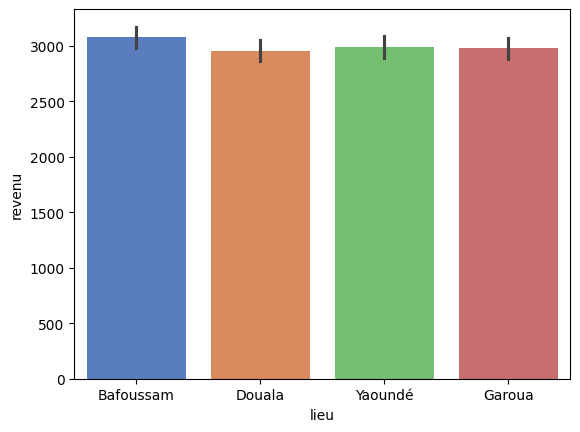

In [18]:
# revenu vs dépenses par lieu
sns.barplot(x='lieu', y='revenu', data=data, palette='muted')

<Axes: xlabel='actifs', ylabel='capital'>

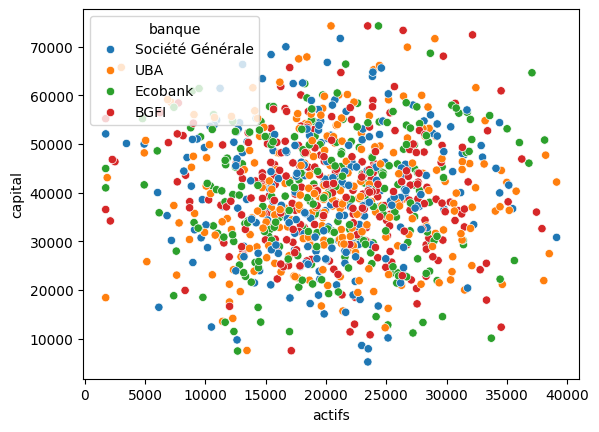

In [19]:
# scatter : actifs vs capital, coloré par banque
sns.scatterplot(x='actifs', y='capital', hue='banque', data=data)

<Axes: xlabel='flux_tresorerie', ylabel='bilan_financier'>

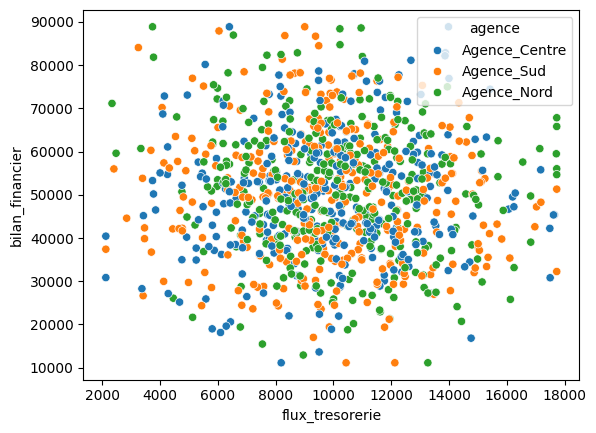

In [20]:
# scatter : flux_tresorerie vs bilan_financier, coloré par agence
sns.scatterplot(x='flux_tresorerie', y='bilan_financier', hue='agence', data=data)

<Axes: >

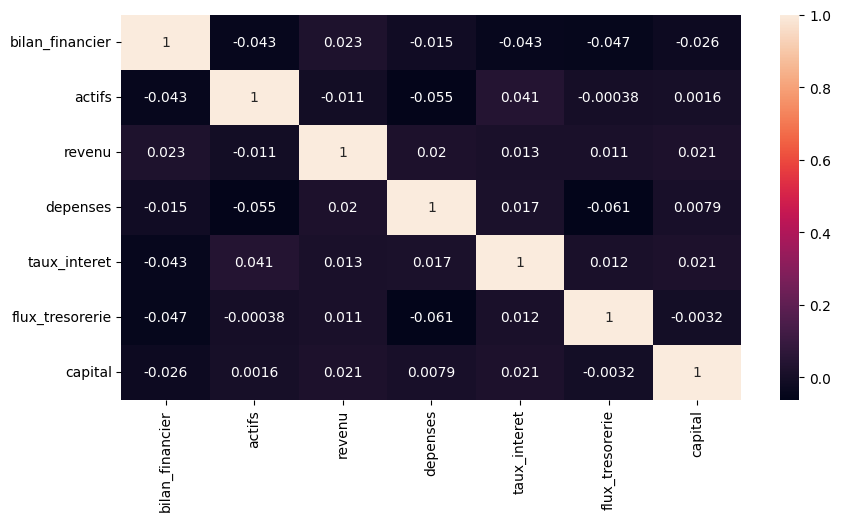

In [21]:
# déterminer la corrélation
plt.figure(figsize=(10, 5))
sns.heatmap(data.select_dtypes(include=['number']).corr(), annot=True)
# si la corrélation arrive à 0.8 il y a un problème donc on peut:
# soit supprimer une des deux colonnes corrélées

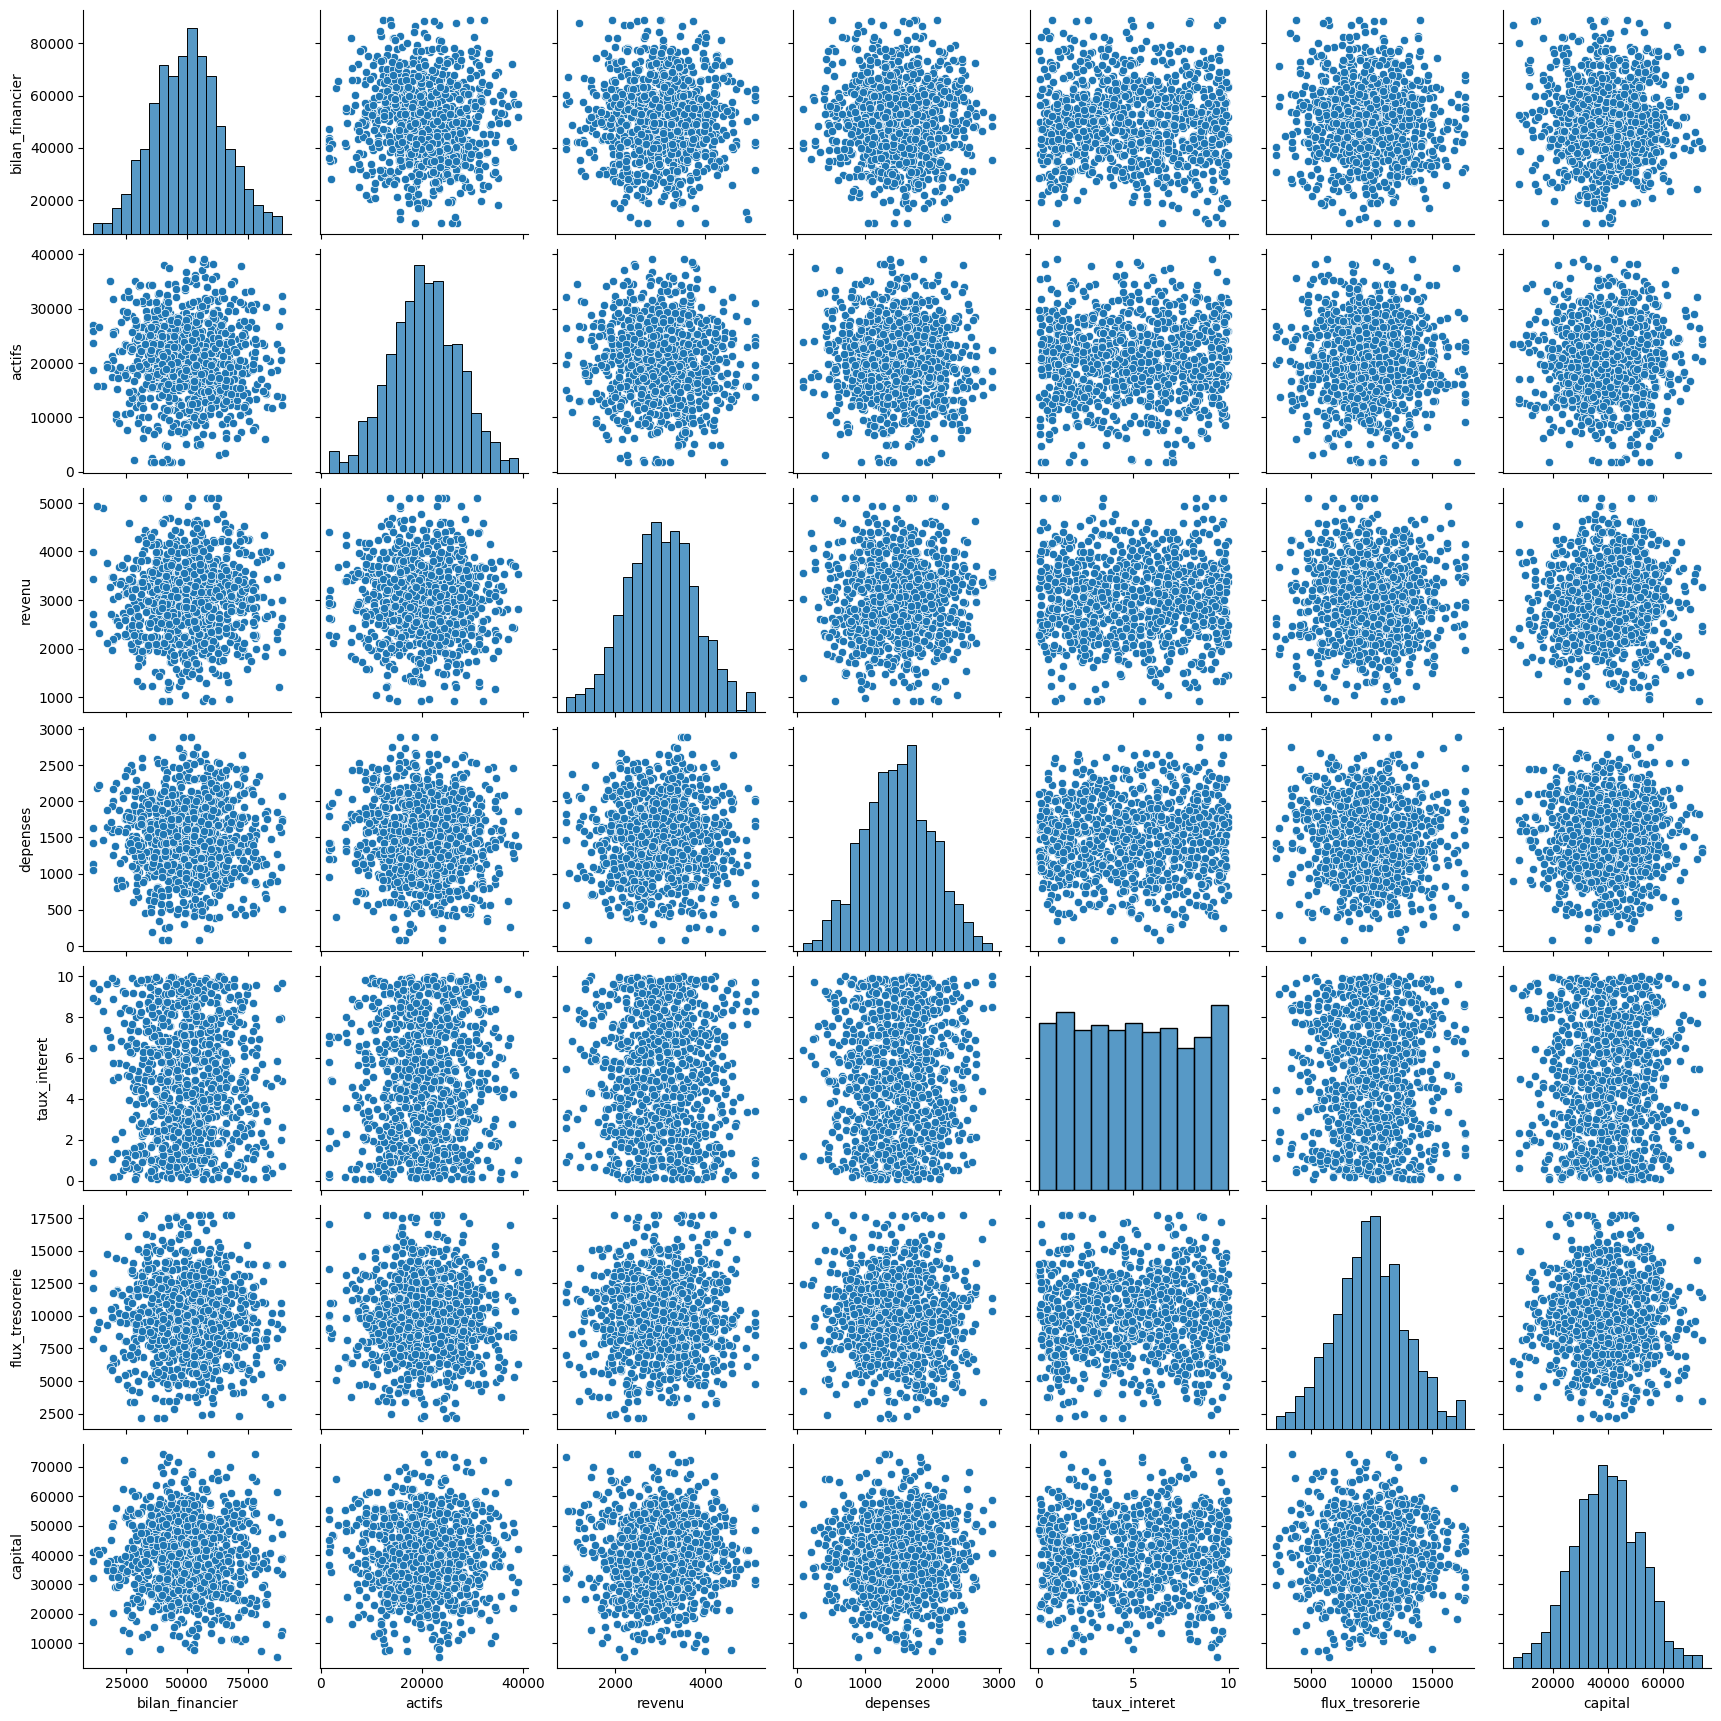

In [22]:
# PAIRPLOT : on sélectionne seulement les valeurs numériques
sns.pairplot(data.select_dtypes(include=['number']))

## Encodage

In [23]:
data.head()

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence,banque,lieu
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,Agence_Centre,Société Générale,Bafoussam
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,Agence_Centre,UBA,Douala
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,74275.905097,Agence_Sud,UBA,Bafoussam
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,Agence_Centre,UBA,Douala
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,Agence_Centre,Ecobank,Bafoussam


In [24]:
# encodage des variables catégorielles
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['banque_enc'] = le.fit_transform(data['banque'])
data['lieu_enc'] = le.fit_transform(data['lieu'])
data['agence_enc'] = le.fit_transform(data['agence'])
data.head()

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence,banque,lieu,banque_enc,lieu_enc,agence_enc
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,Agence_Centre,Société Générale,Bafoussam,2,0,0
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,Agence_Centre,UBA,Douala,3,1,0
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,74275.905097,Agence_Sud,UBA,Bafoussam,3,0,2
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,Agence_Centre,UBA,Douala,3,1,0
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,Agence_Centre,Ecobank,Bafoussam,1,0,0
